### Exploratory analysis

In [54]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import rioxarray
import xcdat as xc
from rioxarray.exceptions import NoDataInBounds

from pathlib import Path
# import matplotlib.gridspec as gridspec
# import pyvinecopulib as pv
# import seaborn as sns
# from py_banshee.copula_test import cvm_statistic
# from scipy.interpolate import interp1d

In [2]:
lon_min, lon_max = -8.5, -1.5
lat_min, lat_max = 40.5, 43.5

In [55]:
def importgriddeddata(datafileloc, lonbounds, latbounds, catchmentfileloc, resultloc):
    dset = xr.open_dataset(datafileloc)
    
    variablename = list(dset.keys())[0]

    # # Rough catchment area
    # lon_min, lon_max = lonbounds
    # lat_min, lat_max = latbounds

    # ds = dset.sel(
    #     longitude=slice(lon_min, lon_max),
    #     latitude=slice(lat_min, lat_max)  # reverse if lat is stored N→S
    # )
    ds=dset

    # Set spatial dimensions (adjust names to match your file)
    drop_vars = [v for v in ['longitude_bnds', 'latitude_bnds', 'time_bnds'] if v in ds.variables]
    ds = ds.drop_vars(drop_vars)

    ds = ds.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
    ds = ds.rio.write_crs("EPSG:4326")

    # Load shapefile
    catchment = gpd.read_file(catchmentfileloc)#.to_crs("EPSG:4326")

    # Clip to catchment shape
    # ds_clipped = ds.rio.clip(catchment.geometry, catchment.crs, drop=True)
    

    try:
        ds_clipped = ds.rio.clip(catchment.geometry, catchment.crs, drop=True)
    except NoDataInBounds:
        print(f"No data in bounds for {catchmentfileloc} — skipping.")
        dset.close()
        return None

    print(datafileloc)

    ds_clipped = ds_clipped.bounds.add_missing_bounds(axes=["X", "Y"])

    #plot an example
    # example = ds_clipped.isel(time = 1000)
    # example[variablename].plot()
    # save clipped version
    # ds_clipped.to_netcdf(resultloc)

    #do spatial averaging over clipped catchment
    # ds_mean = ds_clipped.spatial.average(variablename, axis=["longitude", "latitude"])

    return ds_clipped

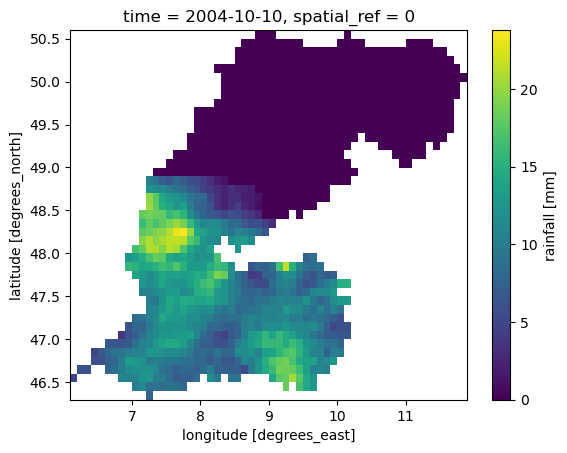

In [ ]:
# # temp_mean = importgriddeddata('Data/temp_eu.nc', (lon_min, lon_max), (lat_min, lat_max),  'Data/duoro.shx', 'Data/Duoro_up_prec.nc')

# lon_min, lon_max = 4.831, 12.821
# lat_min, lat_max = 45.134, 51.670

# Rijn_prec = importgriddeddata('Data/prec_eu.nc', (lon_min, lon_max), (lat_min, lat_max),  'Data/rijn.shx', 'Data/Rijn_up_prec.nc')

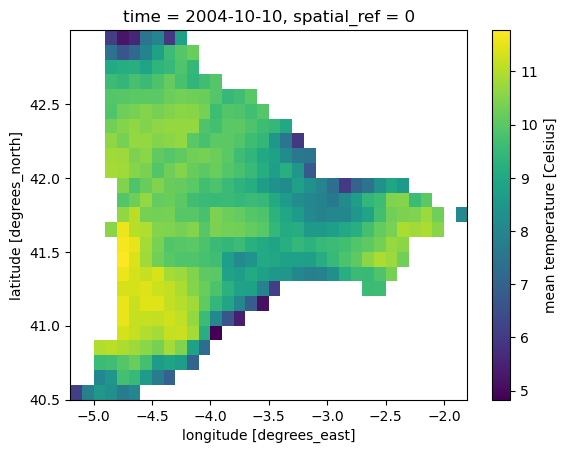

In [4]:
temp_mean = importgriddeddata('Data/temp_eu.nc', (lon_min, lon_max), (lat_min, lat_max),  'Data/duoro.shx', 'Data/Duoro_up_T.nc')

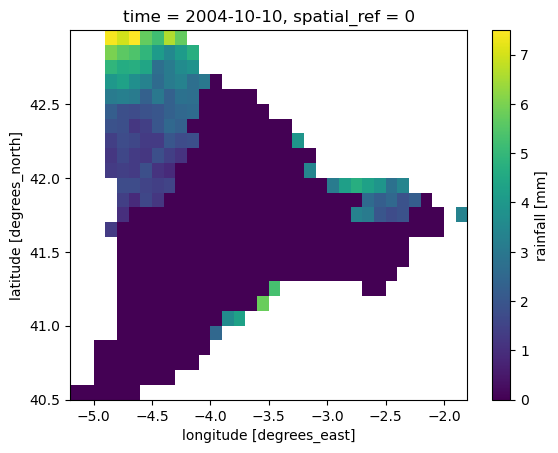

In [5]:
prec_mean = importgriddeddata('Data/prec_eu.nc', (lon_min, lon_max), (lat_min, lat_max),  'Data/duoro.shx', 'Data/Duoro_up_P.nc')

In [ ]:
#C:/Users/nunoh/Desktop/THESIS/OriginalData/RainTempEurope/RainEU.nc

In [57]:
def IsolateRegion(filename, savename):

    P_grid = importgriddeddata('Data/Rijn_up_prec.nc', (lon_min, lon_max), (lat_min, lat_max),
                                filename, 'Data/testprec.nc')
    if P_grid is None:
        return

    T_grid = importgriddeddata('Data/Rijn_up_temp.nc', (lon_min, lon_max), (lat_min, lat_max),
                                filename, 'Data/testtemp.nc')
    if T_grid is None:
        return

    T_grid = T_grid.assign_coords(
        longitude=P_grid.longitude,
        latitude=P_grid.latitude,
    )

    ds = xr.Dataset({
        "P": P_grid["rr"],
        "T": T_grid["tg"],
    })

    ds.to_netcdf(savename)

    return

In [36]:
def find_shx_files(folder):
    folder = Path(folder)
    return [str(f) for f in folder.glob("*.shx")]

In [48]:
shx_files = find_shx_files('C:/Users/nunoh/Desktop/THESIS/OriginalData/AllCatchments')

In [58]:
for pathname in shx_files:
    IsolateRegion(pathname, f"Data/Shapes/{pathname[-19:-4]}.nc")

Data/Rijn_up_prec.nc
Data/Rijn_up_temp.nc
Data/Rijn_up_prec.nc
Data/Rijn_up_temp.nc
Data/Rijn_up_prec.nc
Data/Rijn_up_temp.nc
Data/Rijn_up_prec.nc
Data/Rijn_up_temp.nc
Data/Rijn_up_prec.nc
Data/Rijn_up_temp.nc


2026-09-02 18:12:46,476 [WARNING]: bounds.py(add_missing_bounds:192) >> Cannot generate bounds for coordinate variable 'latitude' which has a length <= 1 (singleton).


Data/Rijn_up_prec.nc


2026-09-02 18:12:48,170 [WARNING]: bounds.py(add_missing_bounds:192) >> Cannot generate bounds for coordinate variable 'latitude' which has a length <= 1 (singleton).


Data/Rijn_up_temp.nc


...

Data/Rijn_up_temp.nc
No data in bounds for C:\Users\nunoh\Desktop\THESIS\OriginalData\AllCatchments\grdc_no_6935550.shx — skipping.
Data/Rijn_up_prec.nc
Data/Rijn_up_temp.nc


2026-09-02 18:23:39,535 [WARNING]: bounds.py(add_missing_bounds:192) >> Cannot generate bounds for coordinate variable 'longitude' which has a length <= 1 (singleton).
2026-09-02 18:23:39,545 [WARNING]: bounds.py(add_missing_bounds:192) >> Cannot generate bounds for coordinate variable 'latitude' which has a length <= 1 (singleton).


Data/Rijn_up_prec.nc


2026-09-02 18:23:41,841 [WARNING]: bounds.py(add_missing_bounds:192) >> Cannot generate bounds for coordinate variable 'longitude' which has a length <= 1 (singleton).
2026-09-02 18:23:41,850 [WARNING]: bounds.py(add_missing_bounds:192) >> Cannot generate bounds for coordinate variable 'latitude' which has a length <= 1 (singleton).


Data/Rijn_up_temp.nc
No data in bounds for C:\Users\nunoh\Desktop\THESIS\OriginalData\AllCatchments\grdc_no_6935580.shx — skipping.
Data/Rijn_up_prec.nc
Data/Rijn_up_temp.nc
Data/Rijn_up_prec.nc
Data/Rijn_up_temp.nc
